# Phase 1 : Baseline Surrogate: Pointwise MLP

**Project:** A data-driven surrogate for airfoil shape optimization, built on the AirfRANS benchmark

**Author:** Muhammad Uns Haider Shah

## Objective
Train the simplest credible surrogate for the AirfRANS *scarce* task: a multilayer perceptron applied independently at every mesh node, mapping node features to the four flow fields $(U_x, U_y, p, \nu_t)$. It has no graph structure or attention, and serves as the reference point for all later comparisons.

## Setup summary
| item | choice |
|---|---|
| data | *scarce* training split (200 cases) → 160 train / 40 validation; *full* test split (200 cases) |
| inputs (7) | $x, y$, inlet velocity $(u_\infty\cos\alpha, u_\infty\sin\alpha)$, signed distance, surface normal |
| outputs (4) | $U_x, U_y, p/\rho, \nu_t$, each standardised separately |
| sampling | 32,000 random nodes per case per epoch (of ~180,000), plus a separate surface sample |
| loss | volume MSE + surface MSE (force coefficients depend only on surface values) |
| checkpointing | to Google Drive, so training resumes after a Colab disconnect |

**Runtime:** Google Colab with a GPU (Runtime → Change runtime type → T4 GPU). Requires the Drive dataset cache created in Phase 0.

## 1. Environment

In [ ]:
# pyvista is pinned: 0.49+ requires a newer IPython than the Colab runtime provides
!pip install -q airfrans "pyvista==0.48.0" "vtk<9.7"
import airfrans as af
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch, torch.nn as nn
import os, glob, json, time, gc

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE, '|', torch.cuda.get_device_name(0) if DEVICE.type == 'cuda' else 'NO GPU: change the runtime type')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 90.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.0/146.0 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.4/242.4 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.0/273.0 kB 25.2 MB/s eta 0:00:00
device: cuda | Tesla T4


## 2. Configuration
All hyperparameters in one place. They are saved with every checkpoint, and a resumed run must use the same values.

In [ ]:
CFG = dict(
    seed           = 0,
    n_val          = 40,        # validation cases held out from the 200 training cases
    width          = 256,       # hidden units per layer
    depth          = 5,         # number of hidden layers
    epochs         = 1000,      # one epoch = one sample from every training case
    cases_per_step = 8,         # training cases per optimisation step
    n_vol          = 32_000,    # random nodes per case per step
    n_surf         = 2_000,     # random surface nodes per case per step (with replacement)
    lambda_surf    = 1.0,       # weight of the surface loss term
    lr             = 1e-3,      # peak learning rate (one-cycle schedule)
    val_every      = 25,        # epochs between validation / checkpoints
)
IN_COLS  = [0, 1, 2, 3, 4, 5, 6]     # x, y, uinf_x, uinf_y, sdf, nx, ny
OUT_COLS = [7, 8, 9, 10]             # Ux, Uy, p, nut
OUT_NAMES = ['Ux', 'Uy', 'p', 'nut']
SURF_COL = 11

torch.manual_seed(CFG['seed']); np.random.seed(CFG['seed'])

## 3. Dataset
The dataset is restored from the Google Drive cache created in Phase 0.

In [ ]:
import shutil, zipfile
from google.colab import drive

USE_DRIVE = True
DRIVE_DIR = '/content/drive/MyDrive/airfrans'
DRIVE_ZIP = f'{DRIVE_DIR}/Dataset.zip'
ROOT_DL   = '/content/airfrans_data'
LOCAL_ZIP = f'{ROOT_DL}/Dataset.zip'

def have_data():
    return bool(glob.glob(f'{ROOT_DL}/**/manifest.json', recursive=True))

def gb(path):
    return os.path.getsize(path) / 1e9

if USE_DRIVE:
    drive.mount('/content/drive')
    os.makedirs(DRIVE_DIR, exist_ok=True)
os.makedirs(ROOT_DL, exist_ok=True)

if have_data():
    print('Dataset already extracted on this machine.')
elif USE_DRIVE and os.path.exists(DRIVE_ZIP):
    print(f'Copying {gb(DRIVE_ZIP):.1f} GB zip from Drive (unzipping from local disk is much faster)...')
    shutil.copy(DRIVE_ZIP, LOCAL_ZIP)
    print('Unzipping...')
    with zipfile.ZipFile(LOCAL_ZIP) as z:
        z.extractall(ROOT_DL)
else:
    print('No cached copy found. Downloading from the AirfRANS server (slow, one time only)...')
    af.dataset.download(root=ROOT_DL, file_name='Dataset', unzip=True, OpenFOAM=False)

# Cache to Drive if it isn't there yet. This only runs after a successful unzip,
# so a broken or partial download never gets saved.
if USE_DRIVE and os.path.exists(LOCAL_ZIP) and have_data():
    if not os.path.exists(DRIVE_ZIP) or gb(DRIVE_ZIP) != gb(LOCAL_ZIP):
        print(f'Saving {gb(LOCAL_ZIP):.1f} GB zip to Drive (10-20 min, one time only)...')
        shutil.copy(LOCAL_ZIP, DRIVE_ZIP)
    print(f'Drive copy OK: {gb(DRIVE_ZIP):.2f} GB  (local {gb(LOCAL_ZIP):.2f} GB)')

print('Data ready:', have_data())

Mounted at /content/drive
Copying 10.0 GB zip from Drive (unzipping from local disk is much faster)...
Unzipping...
Drive copy OK: 10.03 GB  (local 10.03 GB)
Data ready: True


In [ ]:
# The loader needs the folder that contains manifest.json. Find it rather than guessing.
ROOT = os.path.dirname(glob.glob(f'{ROOT_DL}/**/manifest.json', recursive=True)[0])
print('Dataset root:', ROOT)

# Free disk space: the zip is no longer needed locally once extracted
zip_path = f'{ROOT_DL}/Dataset.zip'
if os.path.exists(zip_path):
    os.remove(zip_path)

with open(f'{ROOT}/manifest.json') as f:
    manifest = json.load(f)
for k, v in manifest.items():
    print(f'{k:15s} {len(v):5d} simulations')

Dataset root: /content/airfrans_data/Dataset
full_train        800 simulations
scarce_train      200 simulations
reynolds_train    504 simulations
aoa_train         804 simulations
full_test         200 simulations
reynolds_test     496 simulations
aoa_test          196 simulations


## 4. Utilities

In [ ]:
import numpy as np

def order_surface(pos, normals):
    """Return indices that walk the airfoil surface as a closed loop:
    upper surface leading edge -> trailing edge, then lower surface trailing edge -> leading edge.
    Works whichever way the normals point (inward or outward)."""
    g1 = np.where(normals[:, 1] < 0)[0]
    g2 = np.where(normals[:, 1] >= 0)[0]
    # The upper-surface group is the one sitting higher on average
    upper, lower = (g1, g2) if pos[g1, 1].mean() > pos[g2, 1].mean() else (g2, g1)
    upper = upper[np.argsort(pos[upper, 0])]     # LE -> TE
    lower = lower[np.argsort(-pos[lower, 0])]    # TE -> LE
    return np.concatenate([upper, lower]), len(upper)

def pressure_force_coefficients(pos, normals, p, u_inf, aoa_rad):
    """Integrate surface pressure (kinematic, p/rho) to pressure-only lift and drag coefficients.
    pos, normals, p: surface nodes only. Returns (cd_p, cl_p)."""
    idx, _ = order_surface(pos, normals)
    P, N, pp = pos[idx], normals[idx], p[idx].ravel()
    # Length "owned" by each node = half of each neighbouring segment on the closed loop
    seg = np.linalg.norm(np.roll(P, -1, axis=0) - P, axis=1)
    L = 0.5 * (seg + np.roll(seg, 1))
    # Make normals point OUT of the body: on average they should point away from the centroid
    sign = np.sign(np.mean(np.sum((P - P.mean(axis=0)) * N, axis=1)))
    n_out = sign * N / np.linalg.norm(N, axis=1, keepdims=True)
    F = -(pp[:, None] * n_out * L[:, None]).sum(axis=0)       # force / rho
    drag_dir = np.array([np.cos(aoa_rad), np.sin(aoa_rad)])
    lift_dir = np.array([-np.sin(aoa_rad), np.cos(aoa_rad)])
    q = 0.5 * u_inf**2
    return F @ drag_dir / q, F @ lift_dir / q

def parse_name(name):
    """AirfRANS names look like airFoil2D_SST_<Uinf>_<AoA deg>_<NACA params...>"""
    parts = name.split('_')
    u_inf, aoa = float(parts[2]), float(parts[3])
    naca = [float(v) for v in parts[4:]]
    return u_inf, aoa, naca


## 5. Loading
Simulations are read one at a time and converted to float32 immediately. This mirrors `af.dataset.load` but halves peak memory. The *scarce* task's test set is the *full* task's test set.

In [ ]:
def load_split(key):
    arrays, names = [], []
    for k, s in enumerate(manifest[key]):
        sim = af.Simulation(root=ROOT, name=s)
        u_in = (np.array([np.cos(sim.angle_of_attack), np.sin(sim.angle_of_attack)])
                * sim.inlet_velocity).reshape(1, 2) * np.ones_like(sim.sdf)
        arr = np.concatenate([sim.position, u_in, sim.sdf, sim.normals, sim.velocity,
                              sim.pressure, sim.nu_t, sim.surface.reshape(-1, 1)], axis=-1)
        arrays.append(arr.astype(np.float32)); names.append(s)
        if (k + 1) % 50 == 0:
            print(f'  {key}: {k + 1}/{len(manifest[key])}')
    return arrays, names

t0 = time.time()
train_all, train_all_names = load_split('scarce_train')
test_data, test_names = load_split('full_test')
NU = float(af.Simulation(root=ROOT, name=test_names[0]).NU)
print(f'loaded {len(train_all)} train + {len(test_data)} test cases in {time.time() - t0:.0f} s')

  scarce_train: 50/200
  scarce_train: 100/200
  scarce_train: 150/200
  scarce_train: 200/200
  full_test: 50/200
  full_test: 100/200
  full_test: 150/200
  full_test: 200/200
loaded 200 train + 200 test cases in 189 s


## 6. Train / validation split and normalisation
40 of the 200 training cases are held out for validation and model selection; the test set is not used until the final evaluation. Normalisation statistics are computed on the 160 training cases only.

In [ ]:
rng = np.random.default_rng(CFG['seed'])
perm = rng.permutation(len(train_all))
val_idx, tr_idx = perm[:CFG['n_val']], perm[CFG['n_val']:]
train_data = [train_all[i] for i in tr_idx]; train_names = [train_all_names[i] for i in tr_idx]
val_data   = [train_all[i] for i in val_idx]; val_names   = [train_all_names[i] for i in val_idx]
del train_all; gc.collect()
print(f'train {len(train_data)} | val {len(val_data)} | test {len(test_data)}')

sub = np.concatenate([a[::20] for a in train_data])
x_mean, x_std = sub[:, IN_COLS].mean(0),  sub[:, IN_COLS].std(0)  + 1e-8
y_mean, y_std = sub[:, OUT_COLS].mean(0), sub[:, OUT_COLS].std(0) + 1e-8
del sub
STATS = dict(x_mean=x_mean.tolist(), x_std=x_std.tolist(), y_mean=y_mean.tolist(), y_std=y_std.tolist())
print(pd.DataFrame({'mean': y_mean, 'std': y_std}, index=OUT_NAMES))

train 160 | val 40 | test 200
           mean          std
Ux    41.898457    28.862745
Uy     9.260293    29.078249
p   -357.260620  2413.390869
nut    0.000775     0.002705


All normalised training nodes are placed on the GPU as one tensor (~1.3 GB), so sampling needs no CPU–GPU transfer.

In [ ]:
def to_gpu(cases):
    X = np.concatenate([(c[:, IN_COLS] - x_mean) / x_std for c in cases]).astype(np.float32)
    Y = np.concatenate([(c[:, OUT_COLS] - y_mean) / y_std for c in cases]).astype(np.float32)
    counts = np.array([len(c) for c in cases])
    offsets = np.concatenate([[0], np.cumsum(counts)[:-1]])
    surf = [np.where(c[:, SURF_COL] > 0.5)[0] + o for c, o in zip(cases, offsets)]
    s_counts = np.array([len(s) for s in surf])
    s_offsets = np.concatenate([[0], np.cumsum(s_counts)[:-1]])
    t = lambda a, dt=torch.long: torch.as_tensor(a, dtype=dt, device=DEVICE)
    return dict(X=torch.from_numpy(X).to(DEVICE), Y=torch.from_numpy(Y).to(DEVICE),
                n=t(counts), off=t(offsets), surf=t(np.concatenate(surf)),
                sn=t(s_counts), soff=t(s_offsets))

G = to_gpu(train_data)
print(f"training nodes on {DEVICE}: {G['X'].shape[0]:,}  |  surface nodes per case: "
      f"{int(G['sn'].min())}–{int(G['sn'].max())}")

def sample(case_ids):
    # Random global node indices: n_vol from each whole case, n_surf from each surface
    k = len(case_ids)
    n, off = G['n'][case_ids], G['off'][case_ids]
    iv = (torch.rand(k, CFG['n_vol'], device=DEVICE) * n[:, None]).long() + off[:, None]
    sn, soff = G['sn'][case_ids], G['soff'][case_ids]
    js = (torch.rand(k, CFG['n_surf'], device=DEVICE) * sn[:, None]).long() + soff[:, None]
    return iv.flatten(), G['surf'][js.flatten()]

training nodes on cuda: 28,737,524  |  surface nodes per case: 862–1147


## 7. Model

In [ ]:
class PointwiseMLP(nn.Module):
    def __init__(self, n_in, n_out, width, depth):
        super().__init__()
        layers, d = [], n_in
        for _ in range(depth):
            layers += [nn.Linear(d, width), nn.GELU()]
            d = width
        layers.append(nn.Linear(d, n_out))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

model = PointwiseMLP(len(IN_COLS), len(OUT_COLS), CFG['width'], CFG['depth']).to(DEVICE)
print(model)
print(f'parameters: {sum(p.numel() for p in model.parameters()):,}')

PointwiseMLP(
  (net): Sequential(
    (0): Linear(in_features=7, out_features=256, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): GELU(approximate='none')
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): GELU(approximate='none')
    (6): Linear(in_features=256, out_features=256, bias=True)
    (7): GELU(approximate='none')
    (8): Linear(in_features=256, out_features=256, bias=True)
    (9): GELU(approximate='none')
    (10): Linear(in_features=256, out_features=4, bias=True)
  )
)
parameters: 266,244


## 8. Training setup and checkpoint resume
Checkpoints are written to Drive every `val_every` epochs. If one exists with the same configuration, training continues from it; otherwise it starts fresh. The best model by validation loss is saved separately.

In [ ]:
CKPT_DIR = os.path.join(DRIVE_DIR if USE_DRIVE else '/content', 'phase1')
os.makedirs(CKPT_DIR, exist_ok=True)
CKPT_LAST, CKPT_BEST = f'{CKPT_DIR}/mlp_last.pt', f'{CKPT_DIR}/mlp_best.pt'

steps_per_epoch = int(np.ceil(len(train_data) / CFG['cases_per_step']))
opt = torch.optim.Adam(model.parameters(), lr=CFG['lr'])
sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=CFG['lr'],
                                            total_steps=CFG['epochs'] * steps_per_epoch)
use_amp = DEVICE.type == 'cuda'
scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

start_epoch, best_val = 0, float('inf')
history = dict(epoch=[], train=[], train_vol=[], train_surf=[], val_epoch=[], val=[], val_vol=[], val_surf=[])

if os.path.exists(CKPT_LAST):
    ck = torch.load(CKPT_LAST, map_location=DEVICE, weights_only=False)
    if ck['cfg'] == CFG:
        model.load_state_dict(ck['model']); opt.load_state_dict(ck['opt'])
        sched.load_state_dict(ck['sched']); scaler.load_state_dict(ck['scaler'])
        start_epoch, best_val, history = ck['epoch'], ck['best_val'], ck['history']
        print(f'resumed from epoch {start_epoch} (best val {best_val:.4f})')
    else:
        print('checkpoint found but CFG differs: starting fresh (old checkpoint will be overwritten)')
else:
    print('no checkpoint: starting fresh')

def save_ckpt(path, epoch):
    torch.save(dict(model=model.state_dict(), opt=opt.state_dict(), sched=sched.state_dict(),
                    scaler=scaler.state_dict(), epoch=epoch, best_val=best_val,
                    history=history, cfg=CFG, stats=STATS), path)

no checkpoint: starting fresh


## 9. Training
Validation uses **every node** of the 40 validation cases (no subsampling). If the Colab session disconnects, re-run the notebook from the top: training resumes from the last checkpoint.

In [ ]:
@torch.no_grad()
def predict_norm(case, chunk=400_000):
    # Normalised predictions for all nodes of one case (numpy array in, tensor out)
    X = torch.from_numpy(((case[:, IN_COLS] - x_mean) / x_std).astype(np.float32)).to(DEVICE)
    outs = []
    for i in range(0, len(X), chunk):
        with torch.autocast(DEVICE.type, dtype=torch.float16, enabled=use_amp):
            outs.append(model(X[i:i + chunk]).float())
    return torch.cat(outs)

@torch.no_grad()
def field_errors(cases):
    # Per-field MSE in normalised units, averaged over cases: (volume, surface)
    model.eval()
    vol, srf = [], []
    for c in cases:
        P = predict_norm(c)
        Y = torch.from_numpy(((c[:, OUT_COLS] - y_mean) / y_std).astype(np.float32)).to(DEVICE)
        s = torch.from_numpy(c[:, SURF_COL] > 0.5).to(DEVICE)
        err = (P - Y) ** 2
        vol.append(err.mean(0)); srf.append(err[s].mean(0))
    model.train()
    return torch.stack(vol).mean(0).cpu().numpy(), torch.stack(srf).mean(0).cpu().numpy()

mse = nn.MSELoss()
model.train()
t0 = time.time()
for epoch in range(start_epoch, CFG['epochs']):
    order = torch.randperm(len(train_data), device=DEVICE)
    tot = tv = ts = 0.0
    for b in range(steps_per_epoch):
        iv, isurf = sample(order[b * CFG['cases_per_step']:(b + 1) * CFG['cases_per_step']])
        idx = torch.cat([iv, isurf])
        with torch.autocast(DEVICE.type, dtype=torch.float16, enabled=use_amp):
            pred = model(G['X'][idx]).float()
        target = G['Y'][idx]
        lv = mse(pred[:len(iv)], target[:len(iv)])
        ls = mse(pred[len(iv):], target[len(iv):])
        loss = lv + CFG['lambda_surf'] * ls
        opt.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.step(opt); scaler.update(); sched.step()
        tot += loss.item(); tv += lv.item(); ts += ls.item()
    history['epoch'].append(epoch + 1)
    history['train'].append(tot / steps_per_epoch)
    history['train_vol'].append(tv / steps_per_epoch)
    history['train_surf'].append(ts / steps_per_epoch)

    if (epoch + 1) % CFG['val_every'] == 0 or epoch + 1 == CFG['epochs']:
        v_vol, v_srf = field_errors(val_data)
        v = float(v_vol.mean() + CFG['lambda_surf'] * v_srf.mean())
        history['val_epoch'].append(epoch + 1); history['val'].append(v)
        history['val_vol'].append(float(v_vol.mean())); history['val_surf'].append(float(v_srf.mean()))
        tag = ''
        if v < best_val:
            best_val = v; save_ckpt(CKPT_BEST, epoch + 1); tag = '  * best'
        save_ckpt(CKPT_LAST, epoch + 1)
        print(f'epoch {epoch + 1:5d} | train {history["train"][-1]:.4f} | val {v:.4f} '
              f'(vol {v_vol.mean():.4f}, surf {v_srf.mean():.4f}) | '
              f'lr {sched.get_last_lr()[0]:.1e} | {time.time() - t0:.0f} s{tag}')
print('training complete')

epoch    25 | train 1.0975 | val 1.6901 (vol 1.2339, surf 0.4562) | lr 5.6e-05 | 25 s  * best
epoch    50 | train 0.8355 | val 1.3918 (vol 0.9804, surf 0.4115) | lr 1.0e-04 | 52 s  * best
epoch    75 | train 0.6454 | val 1.1120 (vol 0.7566, surf 0.3554) | lr 1.8e-04 | 81 s  * best
epoch   100 | train 0.5268 | val 0.9377 (vol 0.5916, surf 0.3460) | lr 2.8e-04 | 115 s  * best
epoch   125 | train 0.4874 | val 1.0766 (vol 0.5382, surf 0.5384) | lr 4.0e-04 | 146 s
epoch   150 | train 0.4555 | val 0.9839 (vol 0.5485, surf 0.4354) | lr 5.2e-04 | 177 s
epoch   175 | train 0.4814 | val 0.8496 (vol 0.5000, surf 0.3496) | lr 6.4e-04 | 208 s  * best
epoch   200 | train 0.4878 | val 0.9305 (vol 0.5022, surf 0.4284) | lr 7.6e-04 | 240 s
epoch   225 | train 0.4455 | val 0.9042 (vol 0.4830, surf 0.4212) | lr 8.6e-04 | 271 s
epoch   250 | train 0.3996 | val 0.8368 (vol 0.4677, surf 0.3690) | lr 9.4e-04 | 302 s  * best
epoch   275 | train 0.4124 | val 0.8265 (vol 0.4562, surf 0.3703) | lr 9.8e-04 | 333 

## 10. Training curves

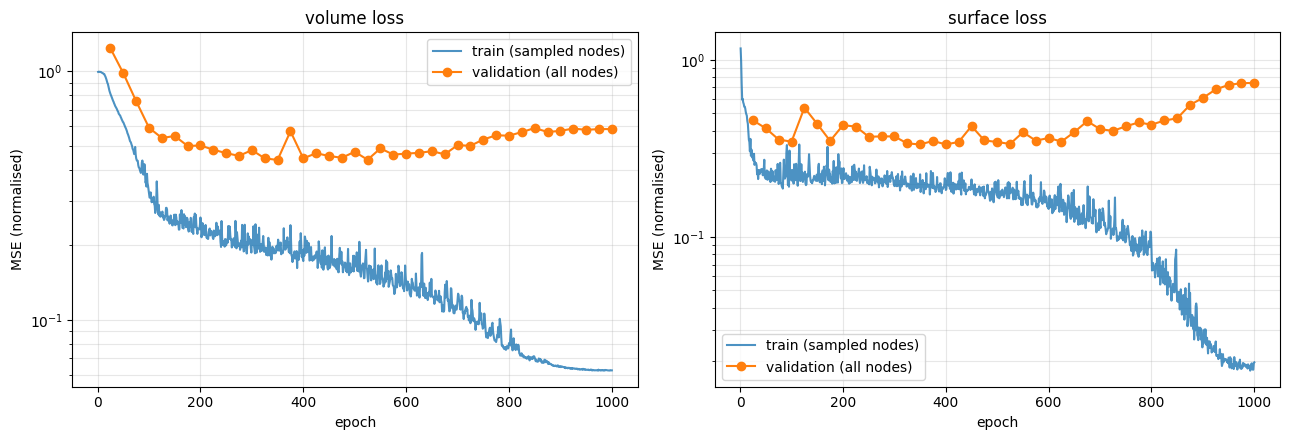

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for a, (tk, vk, title) in zip(ax, [('train_vol', 'val_vol', 'volume loss'),
                                   ('train_surf', 'val_surf', 'surface loss')]):
    a.semilogy(history['epoch'], history[tk], label='train (sampled nodes)', alpha=0.8)
    a.semilogy(history['val_epoch'], history[vk], 'o-', label='validation (all nodes)')
    a.set_xlabel('epoch'); a.set_ylabel('MSE (normalised)'); a.set_title(title)
    a.grid(alpha=0.3, which='both'); a.legend()
plt.tight_layout()
plt.savefig(f'{CKPT_DIR}/training_curves.png', dpi=150); plt.show()

## 11. Test-set evaluation
The best checkpoint (lowest validation loss) is evaluated on all 200 test cases, using every node. Errors are per-field MSE in normalised units, reported separately for the volume and the airfoil surface.

These values use this notebook's normalisation, so they are not numerically identical to published tables. Comparisons with the published baselines are made in Phase 2 on quantities independent of normalisation (force coefficients and their rank correlation).

In [ ]:
best = torch.load(CKPT_BEST, map_location=DEVICE, weights_only=False)
model.load_state_dict(best['model'])
print(f"best checkpoint: epoch {best['epoch']}, validation loss {best['best_val']:.4f}")

t_vol, t_srf = field_errors(test_data)
results = pd.DataFrame({'volume MSE': t_vol, 'surface MSE': t_srf}, index=OUT_NAMES)
results.loc['mean'] = results.mean()
print(results.to_string(float_format=lambda v: f'{v:.5f}'))

best checkpoint: epoch 350, validation loss 0.7732
      volume MSE  surface MSE
Ux       0.21182      0.00056
Uy       0.19323      0.00068
p        0.36005      0.96713
nut      0.24314      0.00019
mean     0.25206      0.24214


## 12. Example prediction
One test case: true and predicted fields near the airfoil, and the surface pressure distribution. Pressure lift is integrated from both, using the Phase 0 routine.

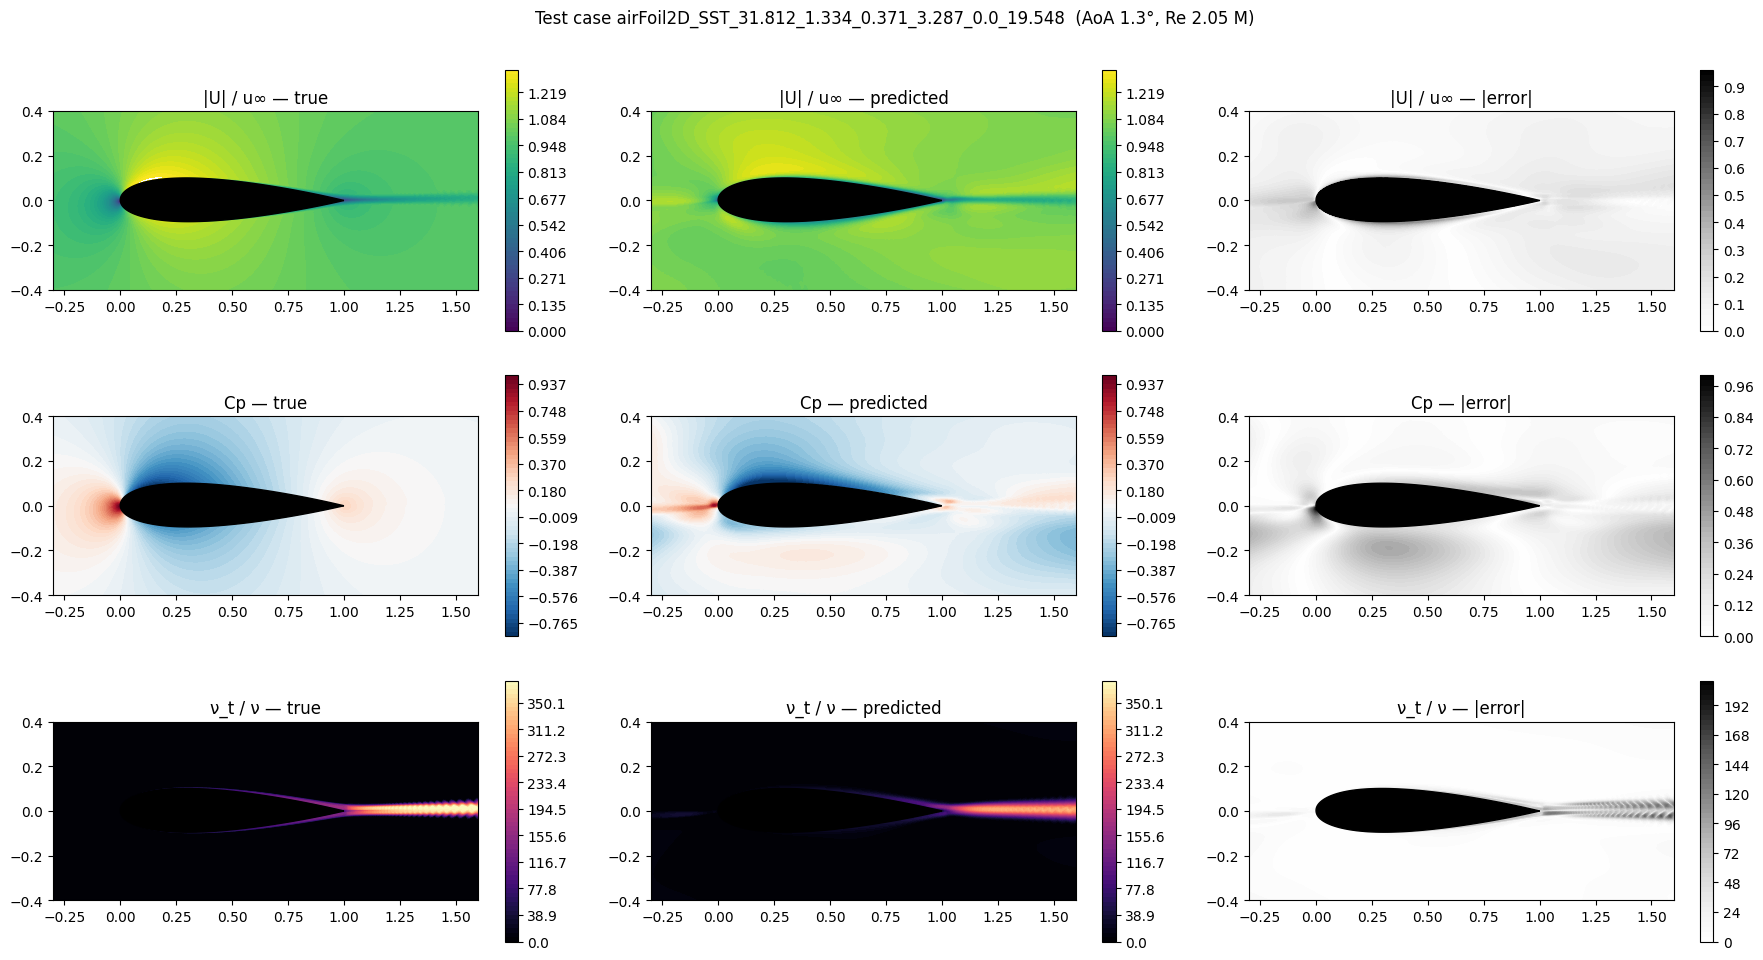

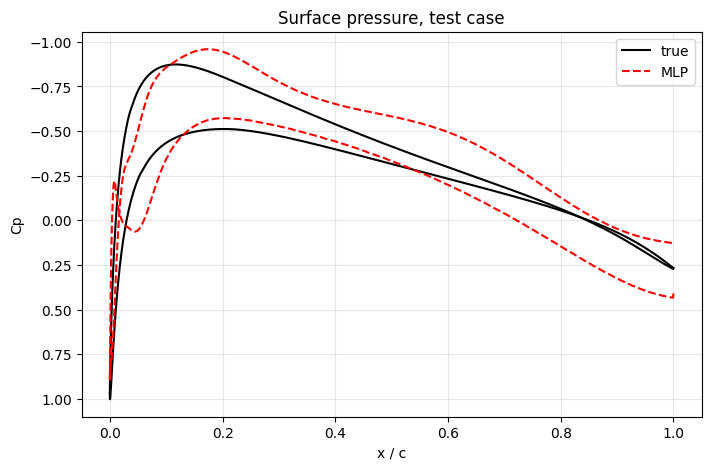

pressure CL: true 0.1494 | MLP 0.2943 | relative error 97.0%


In [ ]:
import matplotlib.tri as mtri
from matplotlib.path import Path

@torch.no_grad()
def predict_physical(case):
    model.eval()
    P = predict_norm(case).cpu().numpy() * y_std + y_mean
    model.train()
    return P

k = 0
c = test_data[k]
u_inf, aoa_deg, naca = parse_name(test_names[k])
P = predict_physical(c)
pos, surf = c[:, :2], c[:, SURF_COL] > 0.5

tri = mtri.Triangulation(pos[:, 0], pos[:, 1])
sidx, n_up = order_surface(pos[surf], c[surf, 5:7])
outline = pos[surf][sidx]
tri.set_mask(Path(outline).contains_points(pos[tri.triangles].mean(axis=1)))

q = 0.5 * u_inf**2
rows = [('|U| / u∞', np.hypot(c[:, 7], c[:, 8]) / u_inf, np.hypot(P[:, 0], P[:, 1]) / u_inf, 'viridis'),
        ('Cp', c[:, 9] / q, P[:, 2] / q, 'RdBu_r'),
        ('ν_t / ν', c[:, 10] / NU, P[:, 3] / NU, 'magma')]
fig, axes = plt.subplots(3, 3, figsize=(18, 10))
for r, (lab, true, pred, cmap) in enumerate(rows):
    lo, hi = np.percentile(true, [0.5, 99.5])
    levels = np.linspace(lo, hi, 60)
    for col, (f, t) in enumerate([(true, 'true'), (pred, 'predicted'), (np.abs(pred - true), '|error|')]):
        ax = axes[r, col]
        cf = ax.tricontourf(tri, np.clip(f, lo, hi) if col < 2 else f,
                            levels=levels if col < 2 else 60, cmap=cmap if col < 2 else 'Greys')
        ax.fill(outline[:, 0], outline[:, 1], color='k')
        ax.set_xlim(-0.3, 1.6); ax.set_ylim(-0.4, 0.4); ax.set_aspect('equal')
        ax.set_title(f'{lab} — {t}'); plt.colorbar(cf, ax=ax, shrink=0.8)
fig.suptitle(f'Test case {test_names[k]}  (AoA {aoa_deg:.1f}°, Re {u_inf / NU / 1e6:.2f} M)')
plt.tight_layout()
plt.savefig(f'{CKPT_DIR}/example_fields.png', dpi=150); plt.show()

sp, sn = pos[surf], c[surf, 5:7]
xs = sp[sidx, 0]
cp_true, cp_pred = c[surf, 9][sidx] / q, P[surf, 2][sidx] / q
plt.figure(figsize=(8, 5))
plt.plot(xs[:n_up], cp_true[:n_up], 'k-', label='true')
plt.plot(xs[n_up:], cp_true[n_up:], 'k-')
plt.plot(xs[:n_up], cp_pred[:n_up], 'r--', label='MLP')
plt.plot(xs[n_up:], cp_pred[n_up:], 'r--')
plt.gca().invert_yaxis(); plt.grid(alpha=0.3); plt.legend()
plt.xlabel('x / c'); plt.ylabel('Cp'); plt.title('Surface pressure, test case')
plt.savefig(f'{CKPT_DIR}/example_cp.png', dpi=150); plt.show()

a = np.radians(aoa_deg)
_, cl_true = pressure_force_coefficients(sp, sn, c[surf, 9], u_inf, a)
_, cl_pred = pressure_force_coefficients(sp, sn, P[surf, 2], u_inf, a)
print(f'pressure CL: true {cl_true:.4f} | MLP {cl_pred:.4f} | relative error {abs(cl_pred / cl_true - 1) * 100:.1f}%')

## 13. Saved artefacts

In [ ]:
summary = dict(cfg=CFG, best_epoch=int(best['epoch']), best_val=float(best['best_val']),
               test_volume_mse=dict(zip(OUT_NAMES, map(float, t_vol))),
               test_surface_mse=dict(zip(OUT_NAMES, map(float, t_srf))),
               n_params=sum(p.numel() for p in model.parameters()),
               val_names=val_names)
with open(f'{CKPT_DIR}/phase1_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
for p in sorted(glob.glob(f'{CKPT_DIR}/*')):
    print(f'{os.path.getsize(p) / 1e6:8.2f} MB  {p}')

    0.09 MB  /content/drive/MyDrive/airfrans/phase1/example_cp.png
    0.33 MB  /content/drive/MyDrive/airfrans/phase1/example_fields.png
    3.22 MB  /content/drive/MyDrive/airfrans/phase1/mlp_best.pt
    3.24 MB  /content/drive/MyDrive/airfrans/phase1/mlp_last.pt
    0.00 MB  /content/drive/MyDrive/airfrans/phase1/phase1_summary.json
    0.13 MB  /content/drive/MyDrive/airfrans/phase1/training_curves.png


## Summary
A pointwise MLP baseline is trained on the *scarce* split with per-field normalisation, per-epoch node subsampling, and a separate surface-loss term. The table in Section 11 reports its field errors on the 200-case test set.

This model sees each node in isolation: it has no information about neighbouring nodes beyond what the signed distance and coordinates encode. The near-wall region, where gradients are steepest, is therefore where its errors are expected to concentrate.

**Results.** Validation loss stops improving after roughly 350 epochs and then rises, while
training loss continues to fall to the end of the 1000-epoch schedule; the final gap is a factor of
about 6 in the volume and 25 on the surface. Model selection on validation loss returns the epoch-350
checkpoint. On the 200 test cases the per-field volume MSEs are 0.212 (Ux), 0.193 (Uy), 0.360 (p)
and 0.243 (νt), with a surface pressure MSE of 0.967 — comparable to the variance of the field
itself. Integrating the predicted surface pressure on the example case gives a pressure lift of
0.294 against a true 0.149.

The surface errors for velocity and turbulent viscosity are small only because these quantities
vanish at a no-slip wall. Pressure is the informative entry, and its magnitude reflects a
structural limitation: a pointwise model observes one node at a time, whereas surface pressure
depends on the entire airfoil. The model therefore memorises the training geometries. Phase 1b
tests this explanation directly by supplying global shape information and changing nothing else.

**Next : Phase 1b:** the same model given a description of the whole airfoil at every node, to test whether the missing global shape information is what limits this baseline. Phase 2 then evaluates both models in aerodynamic terms.